In [18]:
import os #To work with files and folders
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
from IPython.display import Audio

In [19]:
dataset_path = r"E:\Machine Learning Course\Practicle\06_Speech_Emotion_Recognition\Emotion_Recognizatio_Set"

In [20]:
print(os.listdir(dataset_path)[:5])

['Actor_01', 'Actor_02', 'Actor_03', 'Actor_04', 'Actor_05']


In [21]:
# We are taking only 4 emotions

In [22]:
emotion_map = {
    "01": "neutral",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "08": "Surprised"
}

In [23]:
audio_files = []
labels = []

for actor in os.listdir(dataset_path):
    actor_path = os.path.join(dataset_path, actor)

    if os.path.isdir(actor_path) and actor.startswith("Actor_"):
        for file in os.listdir(actor_path):

            if file.endswith(".wav"):
                parts = file.split("-")

                emotion_code = parts[2]

                if emotion_code in emotion_map:
                    audio_files.append(os.path.join(actor_path, file))
                    labels.append(emotion_map[emotion_code])

In [24]:
print("Total selected files:", len(audio_files))
print(labels[:10])

Total selected files: 864
['neutral', 'neutral', 'neutral', 'neutral', 'happy', 'happy', 'happy', 'happy', 'happy', 'happy']


In [25]:
sample_file = audio_files[320]
print("Label:", labels[320])

Audio(sample_file)

Label: Surprised


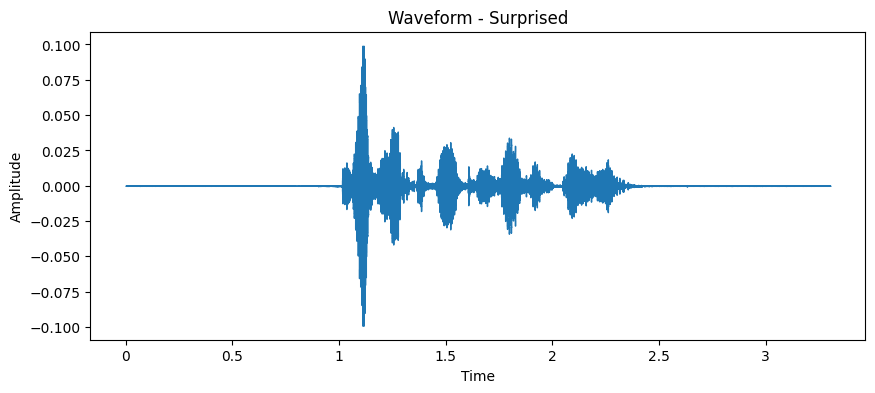

In [26]:
y, sr = librosa.load(sample_file, sr=None)

plt.figure(figsize=(10, 4))
librosa.display.waveshow(y, sr=sr)
plt.title(f"Waveform - {labels[320]}")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()

# Librosa ---> features Extraction

In [27]:
def extract_features(file_path):

    y, sr = librosa.load(file_path, sr=None)

    # MFCC
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfcc_mean = np.mean(mfcc, axis=1)

    # Chroma
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    chroma_mean = np.mean(chroma, axis=1)

    # RMS Energy
    rms = librosa.feature.rms(y=y)
    rms_mean = np.mean(rms)

    # Zero Crossing Rate
    zcr = librosa.feature.zero_crossing_rate(y)
    zcr_mean = np.mean(zcr)

    features = np.hstack([
        mfcc_mean,
        chroma_mean,
        rms_mean,
        zcr_mean
    ])

    return features

#MFCC → voice/tone  pattern
#Chroma → pitch-related information
#RMS Energy → how much voice strong/loud?
#Zero Crossing Rate → how rapidly signal is changing

In [28]:
sample_features = extract_features(sample_file)

print(sample_features)
print("Number of features:", len(sample_features))

[-6.56887268e+02  6.06427307e+01  5.70210361e+00  1.06480074e+01
  8.58075809e+00  1.01746674e+01 -4.10237789e+00 -4.23054755e-01
 -2.01112556e+00 -2.12654877e+00 -8.85784328e-01 -2.11940527e+00
 -3.64435482e+00  5.59683204e-01  5.79207122e-01  5.80480874e-01
  6.03037357e-01  6.43252492e-01  6.54696286e-01  6.79780543e-01
  6.33953393e-01  5.82870305e-01  5.64349174e-01  5.99461854e-01
  5.77609181e-01  2.47664028e-03  6.49618826e-02]
Number of features: 27


# Making the Data Frame

In [29]:
all_features = []

for file_path, label in zip(audio_files, labels):
    features = extract_features(file_path)
    all_features.append(list(features) + [label])

columns = (
    [f"MFCC_{i+1}" for i in range(13)] +
    [f"Chroma_{i+1}" for i in range(12)] +
    ["RMS", "ZCR", "Emotion"]
)

df = pd.DataFrame(all_features, columns=columns)



# EDA

In [30]:
# Visulaizing Data

In [31]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 864 entries, 0 to 863
Data columns (total 28 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   MFCC_1     864 non-null    float64
 1   MFCC_2     864 non-null    float64
 2   MFCC_3     864 non-null    float64
 3   MFCC_4     864 non-null    float64
 4   MFCC_5     864 non-null    float64
 5   MFCC_6     864 non-null    float64
 6   MFCC_7     864 non-null    float64
 7   MFCC_8     864 non-null    float64
 8   MFCC_9     864 non-null    float64
 9   MFCC_10    864 non-null    float64
 10  MFCC_11    864 non-null    float64
 11  MFCC_12    864 non-null    float64
 12  MFCC_13    864 non-null    float64
 13  Chroma_1   864 non-null    float64
 14  Chroma_2   864 non-null    float64
 15  Chroma_3   864 non-null    float64
 16  Chroma_4   864 non-null    float64
 17  Chroma_5   864 non-null    float64
 18  Chroma_6   864 non-null    float64
 19  Chroma_7   864 non-null    float64
 20  Chroma_8  

In [32]:
df.describe()

,MFCC_1,MFCC_2,MFCC_3,MFCC_4,MFCC_5,MFCC_6,MFCC_7,MFCC_8,MFCC_9,MFCC_10,...,Chroma_5,Chroma_6,Chroma_7,Chroma_8,Chroma_9,Chroma_10,Chroma_11,Chroma_12,RMS,ZCR
count,864.000000,864.000000,864.000000,864.000000,864.000000,864.000000,864.000000,864.000000,864.000000,864.000000,...,864.000000,864.000000,864.000000,864.000000,864.000000,864.000000,864.000000,864.000000,864.000000,864.000000
mean,-606.027815,65.167617,-5.881550,9.042310,-0.185520,7.513683,-8.756376,0.595283,-6.847999,-5.955118,...,0.521670,0.533397,0.537568,0.534125,0.530836,0.512333,0.515103,0.501795,0.011425,0.068945
std,102.098246,14.110912,11.593982,7.572914,6.716437,7.084604,6.057978,5.153169,4.604825,4.229916,...,0.103355,0.097719,0.094958,0.093778,0.090742,0.084847,0.081355,0.075735,0.013558,0.017968
min,-863.639221,18.962200,-47.015965,-16.695122,-19.237795,-11.918347,-29.964558,-15.704324,-17.799042,-21.439531,...,0.249821,0.251714,0.247167,0.258059,0.280743,0.263317,0.282616,0.297381,0.000328,0.027717
25%,-683.358978,55.263928,-13.180415,4.193562,-4.844182,2.113219,-12.744741,-2.902928,-10.266114,-8.871565,...,0.447925,0.462636,0.469094,0.464217,0.466484,0.454596,0.461451,0.444915,0.003336,0.056757
50%,-612.646576,64.626328,-5.250850,8.984504,-0.530681,7.769136,-9.181767,0.318556,-7.390957,-5.878669,...,0.529922,0.540040,0.539031,0.537784,0.534406,0.514887,0.514657,0.505152,0.006512,0.066267
75%,-540.994720,75.810589,2.189985,13.649906,4.925686,13.004829,-4.482010,3.962757,-3.431945,-2.734533,...,0.601578,0.608614,0.605703,0.604253,0.595946,0.572700,0.575729,0.557893,0.013042,0.079128
max,-333.377960,110.981491,22.603916,33.428059,20.756651,24.854338,9.462798,14.731714,5.560511,4.400438,...,0.761638,0.807981,0.806110,0.805084,0.795222,0.722524,0.734703,0.683415,0.088503,0.139439


In [33]:
# Cheking Target Distribution
df["Emotion"].value_counts()

Emotion
happy        192
angry        192
sad          192
Surprised    192
neutral       96
Name: count, dtype: int64

In [34]:
# Checking Duplication
df.duplicated().sum()

np.int64(1)

In [35]:
df[df.duplicated()]

,MFCC_1,MFCC_2,MFCC_3,MFCC_4,MFCC_5,MFCC_6,MFCC_7,MFCC_8,MFCC_9,MFCC_10,...,Chroma_6,Chroma_7,Chroma_8,Chroma_9,Chroma_10,Chroma_11,Chroma_12,RMS,ZCR,Emotion
223,-648.888855,93.789574,-5.750032,11.752817,6.618403,14.632291,-5.867281,-0.841661,-10.115385,-5.070194,...,0.623753,0.613721,0.534899,0.501995,0.539796,0.505146,0.425089,0.003983,0.075421,happy


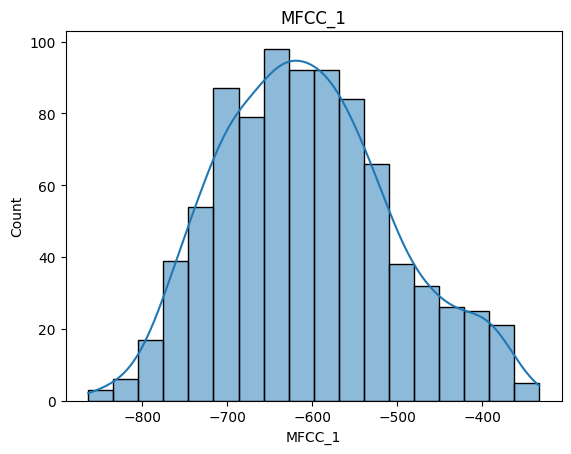

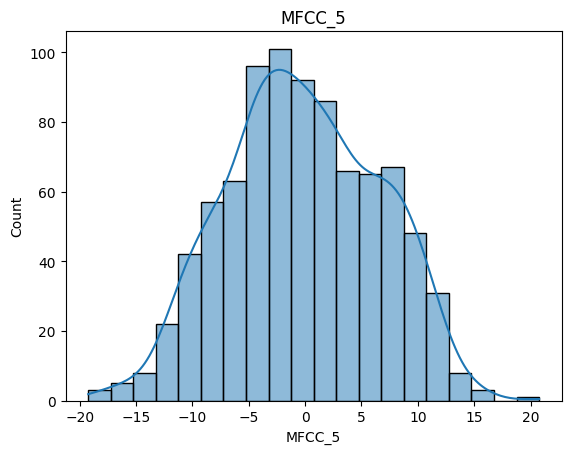

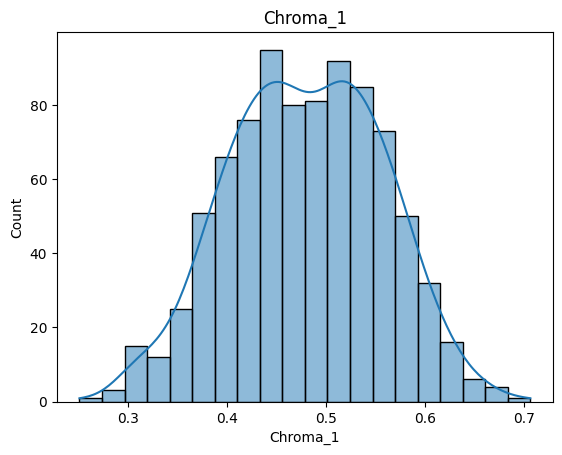

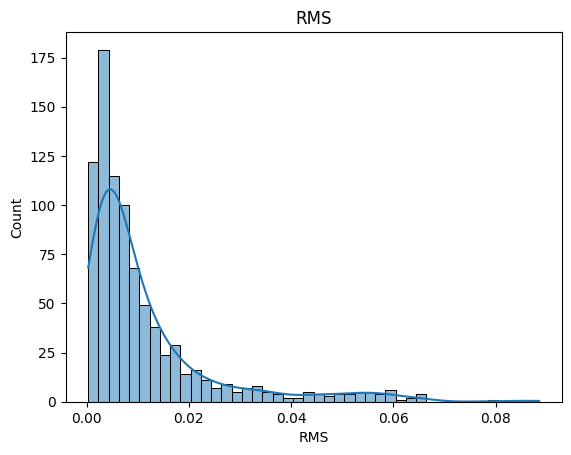

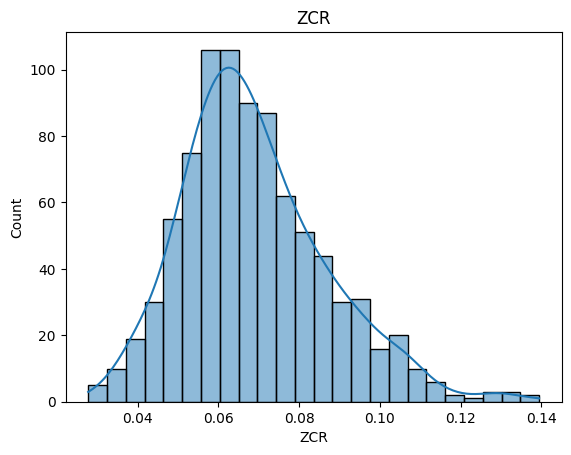

In [36]:
# Visualization
#Histogram
import seaborn as sns

selected_features = ['MFCC_1', 'MFCC_5', 'Chroma_1', 'RMS', 'ZCR']

for fea in selected_features:
    sns.histplot(data=df, x=fea, kde=True)
    plt.title(fea)
    plt.show()

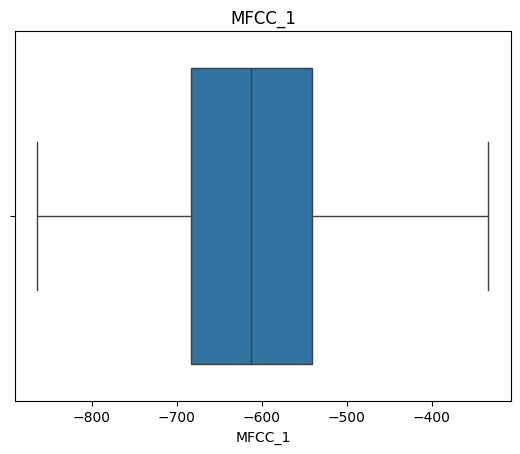

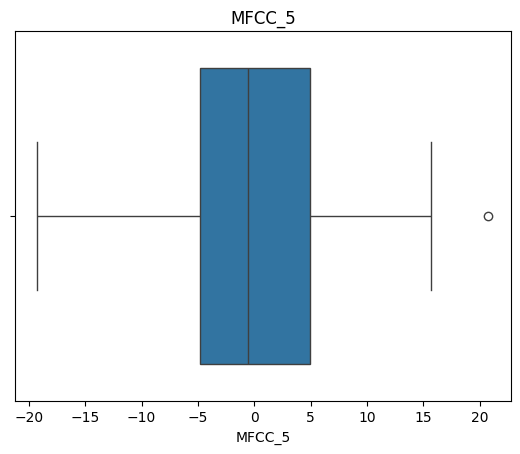

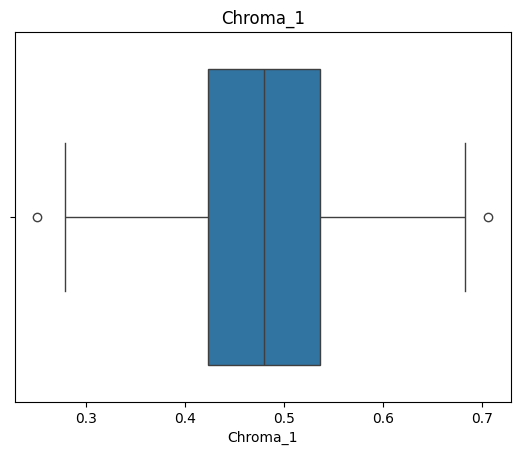

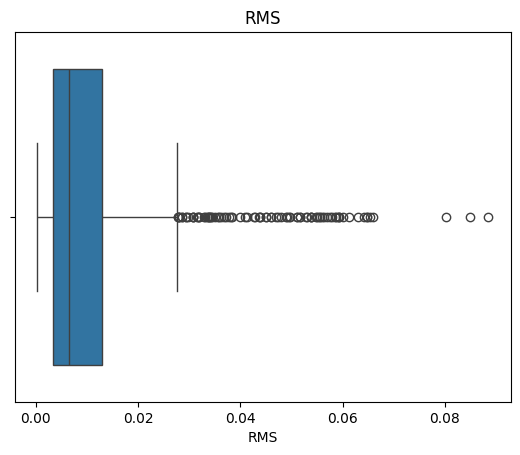

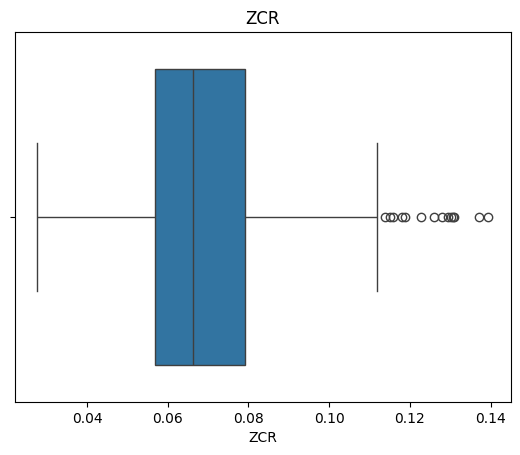

In [37]:
# Box plot
for fea in selected_features:
    sns.boxplot(data=df, x=fea)
    plt.title(fea)
    plt.show()

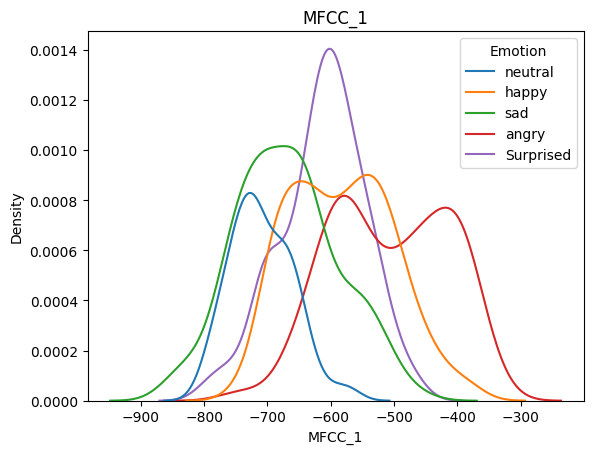

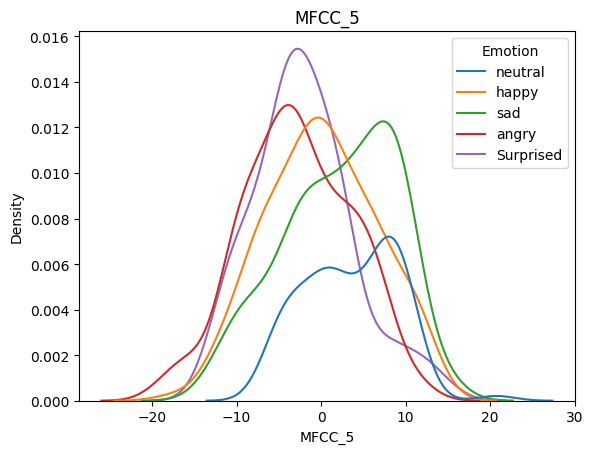

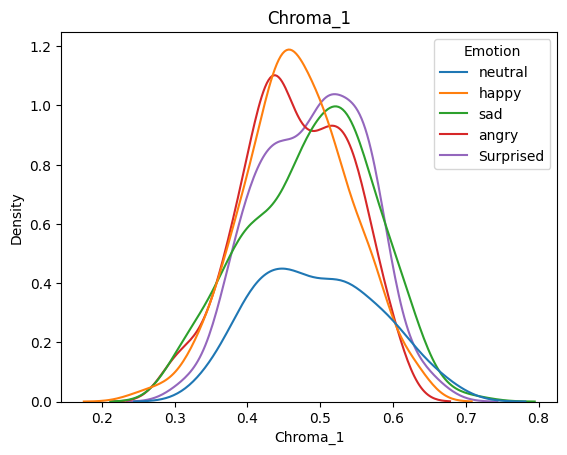

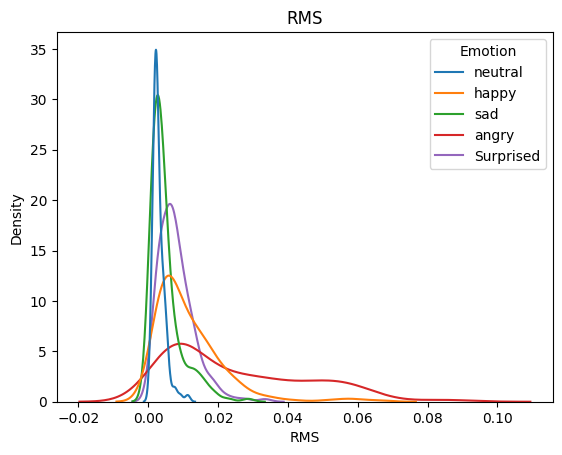

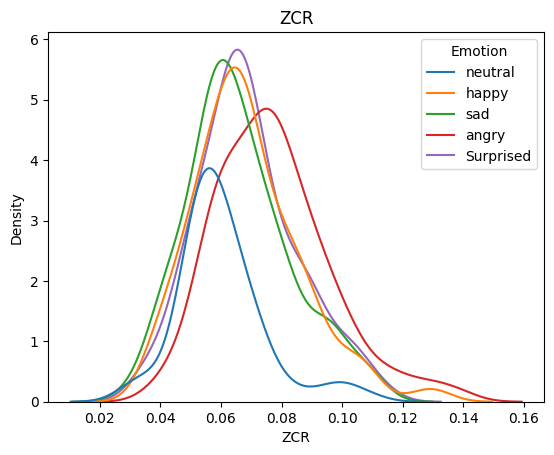

In [38]:
# Target distribution over Features

for fea in selected_features:
    sns.kdeplot(data=df, x=fea, hue="Emotion")
    plt.title(fea)
    plt.show()


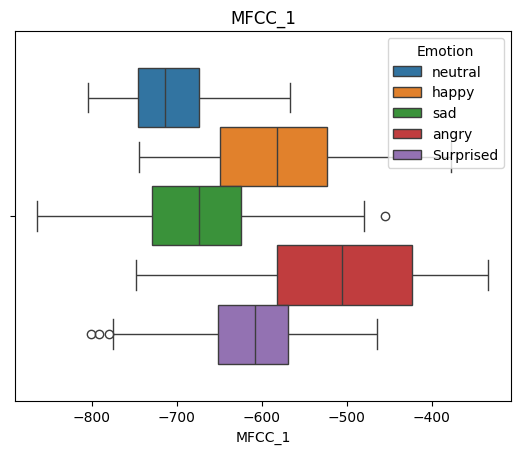

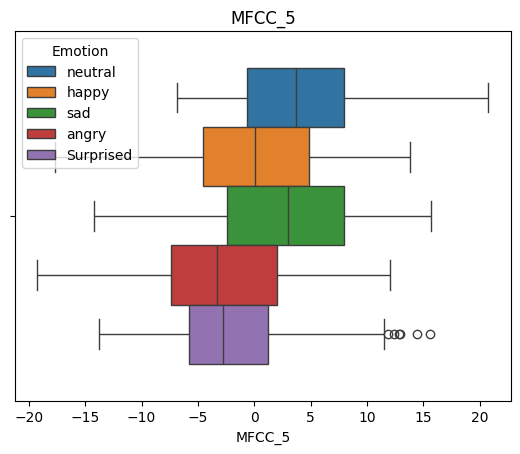

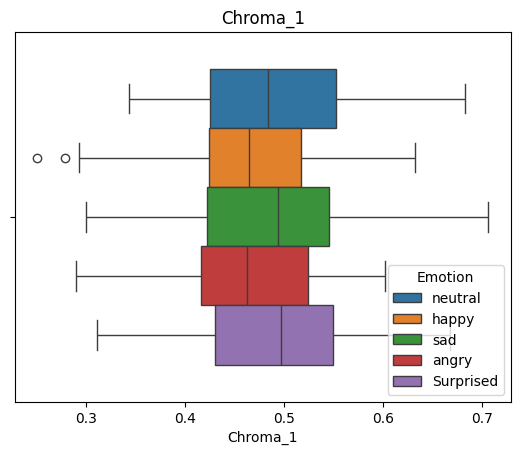

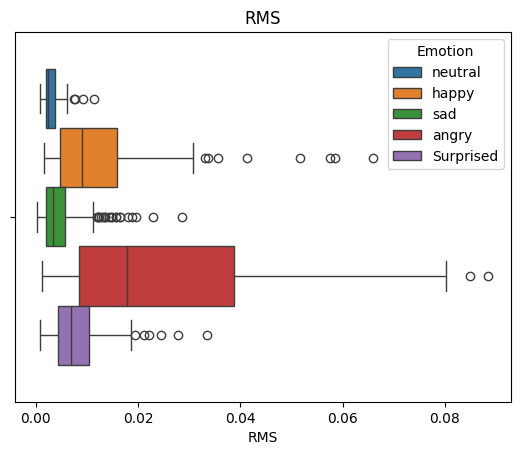

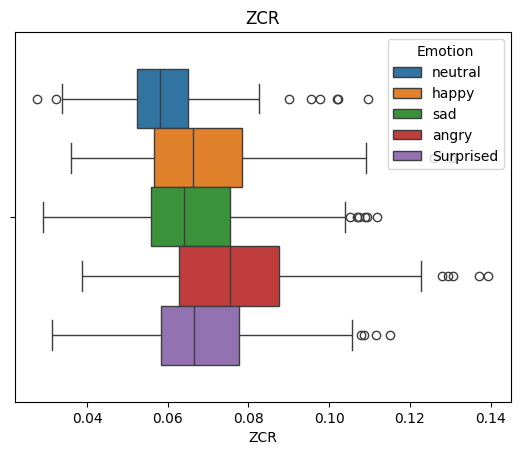

In [39]:

for fea in selected_features:
    sns.boxplot(data=df, x=fea, hue="Emotion")
    plt.title(fea)
    plt.show()


In [40]:
# Emotion classes show noticeable overlap in individual feature distributions,
#suggesting that a combination of multiple audio features will be needed for classification.

# Data Cleaning

In [41]:
#Checking missing values
df.isnull().sum()

MFCC_1       0
MFCC_2       0
MFCC_3       0
MFCC_4       0
MFCC_5       0
MFCC_6       0
MFCC_7       0
MFCC_8       0
MFCC_9       0
MFCC_10      0
MFCC_11      0
MFCC_12      0
MFCC_13      0
Chroma_1     0
Chroma_2     0
Chroma_3     0
Chroma_4     0
Chroma_5     0
Chroma_6     0
Chroma_7     0
Chroma_8     0
Chroma_9     0
Chroma_10    0
Chroma_11    0
Chroma_12    0
RMS          0
ZCR          0
Emotion      0
dtype: int64

In [42]:
# IN EDA we found Duplicated Value so here we will remmove them
df = df.drop_duplicates()

In [43]:
print(df.duplicated().sum())

0


In [44]:
# How many rows left
print(df.shape)

(863, 28)


In [45]:
# Checking for Outliers in RMS and ZCR
Q1 = df["RMS"].quantile(0.25)
Q3 = df["RMS"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

rms_outliers = df[(df["RMS"] < lower) | (df["RMS"] > upper)]
rms_outliers

,MFCC_1,MFCC_2,MFCC_3,MFCC_4,MFCC_5,MFCC_6,MFCC_7,MFCC_8,MFCC_9,MFCC_10,...,Chroma_6,Chroma_7,Chroma_8,Chroma_9,Chroma_10,Chroma_11,Chroma_12,RMS,ZCR,Emotion
24,-382.966064,53.877857,-23.295197,4.590451,-9.281444,-0.877724,-10.370431,-2.316854,-15.354205,-8.757010,...,0.539412,0.538336,0.587426,0.515346,0.443035,0.468202,0.445568,0.051100,0.087503,angry
25,-398.330933,52.281689,-28.397718,12.267397,-10.859696,3.720289,-12.748707,-1.972765,-11.157866,-6.196699,...,0.516873,0.392886,0.361862,0.398094,0.378320,0.404654,0.377900,0.031458,0.113943,angry
26,-433.965759,53.986023,-22.437214,10.337307,-7.014483,4.446643,-9.936925,-1.892736,-10.486032,-7.360679,...,0.569379,0.531213,0.499430,0.537503,0.496725,0.510785,0.448749,0.031654,0.122695,angry
27,-338.979126,44.904930,-24.296865,3.921227,-13.280725,1.456002,-13.051088,-4.972659,-16.886797,-7.368750,...,0.481179,0.478436,0.502798,0.506535,0.394818,0.404822,0.353401,0.088503,0.127859,angry
62,-437.461761,46.474915,-25.999445,-5.887987,-9.137497,-9.274363,-16.633015,1.284062,-11.299037,-13.147175,...,0.528193,0.593795,0.525389,0.488885,0.472666,0.453152,0.441687,0.043675,0.086521,angry
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
816,-455.985199,48.067669,-15.950625,1.535461,-5.581080,-0.848540,-8.292865,-4.907851,-4.379014,-4.583829,...,0.603095,0.569877,0.575428,0.567735,0.525592,0.540413,0.538727,0.034220,0.061972,angry
817,-462.314484,46.190102,-15.609308,-1.256444,-5.659152,-0.085534,-9.750613,-3.665853,-4.687232,-5.173486,...,0.599954,0.577025,0.594475,0.550835,0.507538,0.525257,0.536153,0.033865,0.084273,angry
818,-422.647003,38.850349,-16.750536,-1.020578,-6.937470,-0.109282,-7.619318,-3.343553,-5.698203,-6.035234,...,0.644680,0.658536,0.605610,0.559964,0.532574,0.518981,0.533391,0.040986,0.074339,angry
819,-435.311584,39.688339,-14.456830,0.493589,-5.954214,0.222826,-9.221676,-4.334625,-4.404653,-6.089862,...,0.595560,0.585540,0.567085,0.540371,0.487781,0.518571,0.529362,0.035139,0.077558,angry


In [46]:
# Checking emotion lable for outliers
rms_outliers["Emotion"].value_counts()

Emotion
angry        74
happy        10
Surprised     2
sad           1
Name: count, dtype: int64

In [47]:
#Most RMS outliers belong to the angry class, while only a few occur in other emotions.
#This suggests that these extreme RMS values may represent genuine differences in speech energy rather than data errors. 
#Therefore, RMS outliers are retained instead of being removed.

In [48]:
Q1 = df["ZCR"].quantile(0.25)
Q3 = df["ZCR"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

zcr_outliers = df[(df["ZCR"] < lower) | (df["ZCR"] > upper)]

zcr_outliers["Emotion"].value_counts()

Emotion
angry        10
happy         3
Surprised     1
Name: count, dtype: int64

In [49]:
# ZCR Outlier Insight
#Most ZCR outliers belong to the angry class, with only a few from other emotions. 
#This suggests that the extreme ZCR values may reflect genuine speech characteristics rather than data errors.
#Therefore, ZCR outliers are retained.

In [50]:
# Checking for fix Logic and Domain Errors
print((df["RMS"] < 0).sum())
print(((df["ZCR"] < 0) | (df["ZCR"] > 1)).sum())

0
0


# Data Pre-processing

In [51]:
from sklearn.preprocessing import LabelEncoder
#done lable encoding for target var, and for target var label doesnot mean order/ranking
le = LabelEncoder()
df = df.copy()

df["Emotion_encoded"] = le.fit_transform(df["Emotion"])

In [52]:
#Before Scaling
X = df.drop(columns=["Emotion", "Emotion_encoded"])
y = df["Emotion_encoded"]

In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [54]:
#Scaling
from sklearn.preprocessing import StandardScaler

Scaler = StandardScaler()

X_train_scaled = Scaler.fit_transform(X_train)
X_test_scaled = Scaler.transform(X_test)


# Model

In [58]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

#Train
model_logistic = LogisticRegression()
model_logistic.fit(X_train_scaled, y_train)

#Predict
y_pred = model_logistic.predict(X_test_scaled)

#Evaluate
accuracy_score(y_test, y_pred)
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))


[[25  4  3  1  5]
 [ 8 25  4  0  2]
 [ 5  9 19  1  4]
 [ 2  0  2  7  8]
 [ 2  0  7  6 24]]
              precision    recall  f1-score   support

           0       0.60      0.66      0.62        38
           1       0.66      0.64      0.65        39
           2       0.54      0.50      0.52        38
           3       0.47      0.37      0.41        19
           4       0.56      0.62      0.59        39

    accuracy                           0.58       173
   macro avg       0.56      0.56      0.56       173
weighted avg       0.58      0.58      0.58       173



In [66]:
# KNN

from sklearn.neighbors import KNeighborsClassifier

# Train
model_knn = KNeighborsClassifier (n_neighbors = 5)
model_knn.fit(X_train_scaled, y_train)

#Predict
y_pred = model_knn.predict(X_test_scaled)

#Evaluate
accuracy_score(y_test, y_pred)
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))


[[32  1  3  2  0]
 [ 8 26  1  3  1]
 [16  4 17  1  0]
 [ 3  0  4  9  3]
 [ 8  2  7 10 12]]
              precision    recall  f1-score   support

           0       0.48      0.84      0.61        38
           1       0.79      0.67      0.72        39
           2       0.53      0.45      0.49        38
           3       0.36      0.47      0.41        19
           4       0.75      0.31      0.44        39

    accuracy                           0.55       173
   macro avg       0.58      0.55      0.53       173
weighted avg       0.61      0.55      0.55       173



In [73]:
# SVM
from sklearn.svm import SVC

#Train
model_svm = SVC(kernel ='rbf')
model_svm.fit(X_train_scaled, y_train)

#Predict
y_pred = model_svm.predict(X_test_scaled)

#Evaluate
accuracy_score(y_test, y_pred)
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))


[[31  1  1  2  3]
 [11 22  2  0  4]
 [ 6  4 25  1  2]
 [ 2  0  1  6 10]
 [ 6  0  3  4 26]]
              precision    recall  f1-score   support

           0       0.55      0.82      0.66        38
           1       0.81      0.56      0.67        39
           2       0.78      0.66      0.71        38
           3       0.46      0.32      0.38        19
           4       0.58      0.67      0.62        39

    accuracy                           0.64       173
   macro avg       0.64      0.60      0.61       173
weighted avg       0.66      0.64      0.63       173



In [74]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier
#Train
model_DT = DecisionTreeClassifier (random_state = 42)
model_DT.fit(X_train, y_train)

#Predict
y_pred = model_DT.predict(X_test)

#Evaluate
accuracy_score(y_test, y_pred)
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))



[[17  6  8  1  6]
 [ 9 18  4  3  5]
 [11  4 13  2  8]
 [ 1  1  2  7  8]
 [ 4  1  1  7 26]]
              precision    recall  f1-score   support

           0       0.40      0.45      0.42        38
           1       0.60      0.46      0.52        39
           2       0.46      0.34      0.39        38
           3       0.35      0.37      0.36        19
           4       0.49      0.67      0.57        39

    accuracy                           0.47       173
   macro avg       0.46      0.46      0.45       173
weighted avg       0.48      0.47      0.46       173



In [75]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model_rf.fit(X_train, y_train)

y_pred = model_rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6936416184971098
[[30  2  3  1  2]
 [ 8 26  2  2  1]
 [ 6  4 25  1  2]
 [ 0  0  3  8  8]
 [ 3  0  2  3 31]]
              precision    recall  f1-score   support

           0       0.64      0.79      0.71        38
           1       0.81      0.67      0.73        39
           2       0.71      0.66      0.68        38
           3       0.53      0.42      0.47        19
           4       0.70      0.79      0.75        39

    accuracy                           0.69       173
   macro avg       0.68      0.67      0.67       173
weighted avg       0.70      0.69      0.69       173



In [76]:
# We are Tunning Random Foerst becaus it performed better then others
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,scoring,'f1_weighted'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [77]:
# Checking best settings
print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best CV Score: 0.6385901216909655


In [80]:
#XG_Boost
from xgboost import XGBClassifier

model_xgb = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric="mlogloss"
)

model_xgb.fit(X_train, y_train)

y_pred = model_xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6763005780346821
[[28  3  4  1  2]
 [ 6 27  3  1  2]
 [ 5  4 26  0  3]
 [ 1  0  2  9  7]
 [ 3  0  2  7 27]]
              precision    recall  f1-score   support

           0       0.65      0.74      0.69        38
           1       0.79      0.69      0.74        39
           2       0.70      0.68      0.69        38
           3       0.50      0.47      0.49        19
           4       0.66      0.69      0.68        39

    accuracy                           0.68       173
   macro avg       0.66      0.66      0.66       173
weighted avg       0.68      0.68      0.68       173

